<a href="https://colab.research.google.com/github/jerry124/Aprendizaje-Automatico/blob/main/Practica_California_Housing_Regresion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Práctica mejorada: Regresión con California Housing

**Autor:** Gerardo Valdez Martínez  
**Tema:** Regresión Lineal, Regresión Polinomial, Ridge, Lasso y Random Forest  
**Dataset:** California Housing  

---

## Objetivo

El objetivo de esta práctica es mejorar el modelo de Regresión Lineal aplicado al dataset **California Housing**.

Primero se entrena una Regresión Lineal básica. Después se aplican mejoras como:

- Ingeniería de características.
- Tratamiento básico de valores extremos.
- Regresión Polinomial.
- Regresión Ridge.
- Regresión Lasso.
- Comparación con Random Forest.

La intención es observar si es posible mejorar el desempeño predictivo sin perder la estructura de una práctica de regresión.


## 1. Importación de librerías

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


## 2. Carga del dataset

Se utiliza el dataset **California Housing**, disponible directamente en `scikit-learn`.  
La variable objetivo es **MedHouseVal**, que representa el valor medio de las viviendas.


In [2]:
california = fetch_california_housing()

df = pd.DataFrame(california.data, columns=california.feature_names)
df["MedHouseVal"] = california.target

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## 3. Exploración inicial

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
MedInc,20640.0,3.870671,1.899822,0.499900,2.563400,3.534800,4.743250,15.000100
HouseAge,20640.0,28.639486,12.585558,1.000000,18.000000,29.000000,37.000000,52.000000
AveRooms,20640.0,5.429000,2.474173,0.846154,4.440716,5.229129,6.052381,141.909091
AveBedrms,20640.0,1.096675,0.473911,0.333333,1.006079,1.048780,1.099526,34.066667
Population,20640.0,1425.476744,1132.462122,3.000000,787.000000,1166.000000,1725.000000,35682.000000
AveOccup,20640.0,3.070655,10.386050,0.692308,2.429741,2.818116,3.282261,1243.333333
Latitude,20640.0,35.631861,2.135952,32.540000,33.930000,34.260000,37.710000,41.950000
Longitude,20640.0,-119.569704,2.003532,-124.350000,-121.800000,-118.490000,-118.010000,-114.310000
MedHouseVal,20640.0,2.068558,1.153956,0.149990,1.196000,1.797000,2.647250,5.000010


In [5]:
df.isnull().sum().to_frame("Valores nulos")

,Valores nulos
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
MedHouseVal,0


## 4. Análisis visual inicial

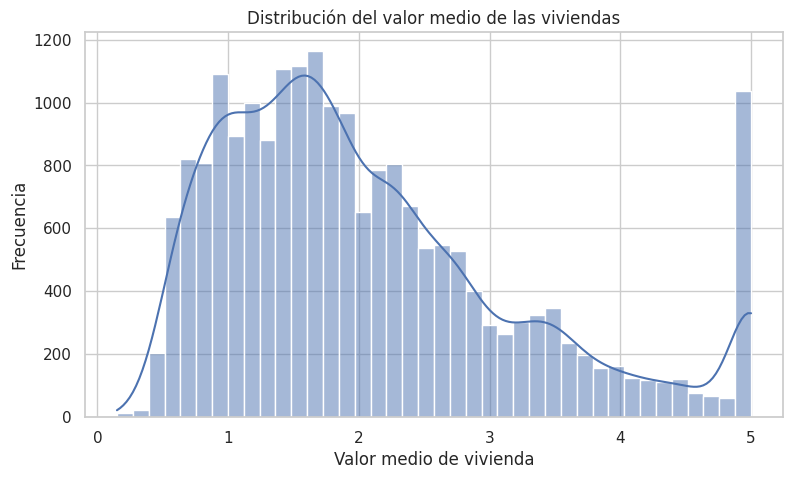

In [6]:
plt.figure(figsize=(9,5))
sns.histplot(df["MedHouseVal"], bins=40, kde=True)
plt.title("Distribución del valor medio de las viviendas")
plt.xlabel("Valor medio de vivienda")
plt.ylabel("Frecuencia")
plt.show()

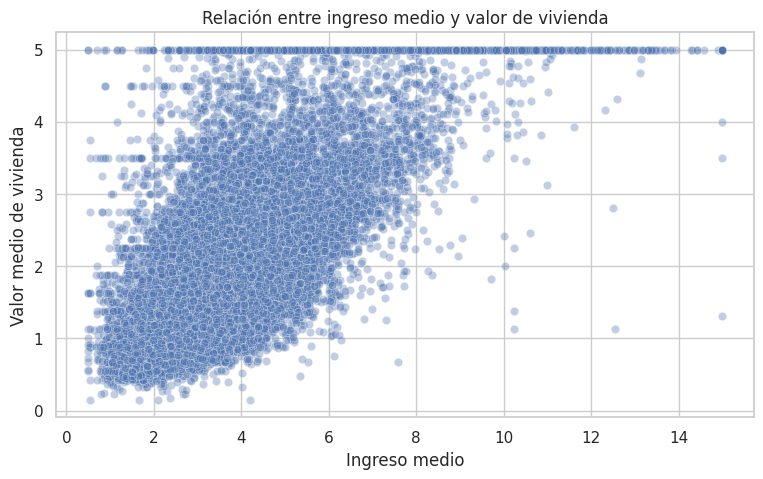

In [7]:
plt.figure(figsize=(9,5))
sns.scatterplot(data=df, x="MedInc", y="MedHouseVal", alpha=0.35)
plt.title("Relación entre ingreso medio y valor de vivienda")
plt.xlabel("Ingreso medio")
plt.ylabel("Valor medio de vivienda")
plt.show()

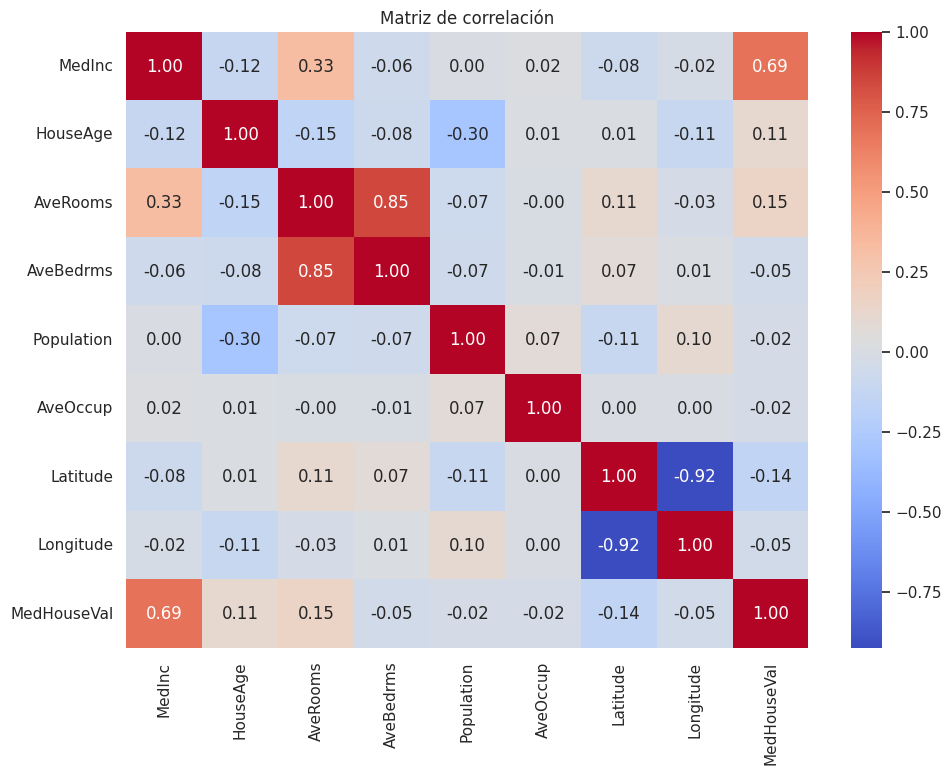

In [8]:
plt.figure(figsize=(11,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de correlación")
plt.show()

## 5. Modelo base: Regresión Lineal

Primero se entrena un modelo básico de Regresión Lineal.  
Este modelo será la referencia para comparar si las mejoras realmente ayudan.


In [9]:
X = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

modelo_lr = LinearRegression()
modelo_lr.fit(X_train_scaled, y_train)

y_pred_lr = modelo_lr.predict(X_test_scaled)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_test, y_pred_lr)

resultados = []

resultados.append({
    "Modelo": "Regresión Lineal Base",
    "MAE": mae_lr,
    "MSE": mse_lr,
    "RMSE": rmse_lr,
    "R2": r2_lr
})

pd.DataFrame(resultados)

,Modelo,MAE,MSE,RMSE,R2
0,Regresión Lineal Base,0.5332,0.555892,0.745581,0.575788


## 6. Ingeniería de características

Para mejorar la regresión se crean nuevas variables a partir de las existentes.

La idea es ayudar al modelo a encontrar relaciones que no son tan evidentes usando solamente las variables originales.


In [10]:
df_mejorado = df.copy()

# Nuevas variables
df_mejorado["RoomsPerPerson"] = df_mejorado["AveRooms"] / df_mejorado["AveOccup"]
df_mejorado["BedroomsPerRoom"] = df_mejorado["AveBedrms"] / df_mejorado["AveRooms"]
df_mejorado["PopulationPerHouseAge"] = df_mejorado["Population"] / (df_mejorado["HouseAge"] + 1)
df_mejorado["IncomePerOccupant"] = df_mejorado["MedInc"] / df_mejorado["AveOccup"]

df_mejorado.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal,RoomsPerPerson,BedroomsPerRoom,PopulationPerHouseAge,IncomePerOccupant
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526,2.732919,0.146591,7.666667,3.257687
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585,2.956685,0.155797,109.136364,3.934608
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521,2.957661,0.129516,9.358491,2.589838
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413,2.283154,0.184458,10.528302,2.214765
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422,2.879646,0.172096,10.660377,1.763125


## 7. Tratamiento básico de valores extremos

Algunas variables tienen valores muy altos que pueden afectar a la Regresión Lineal.

Aquí se aplica un recorte por percentiles para reducir el impacto de valores extremos, sin eliminar gran cantidad de datos.


In [11]:
df_limpio = df_mejorado.copy()

columnas_recorte = [
    "AveRooms",
    "AveBedrms",
    "Population",
    "AveOccup",
    "RoomsPerPerson",
    "BedroomsPerRoom",
    "PopulationPerHouseAge",
    "IncomePerOccupant"
]

for col in columnas_recorte:
    limite_inferior = df_limpio[col].quantile(0.01)
    limite_superior = df_limpio[col].quantile(0.99)
    df_limpio[col] = df_limpio[col].clip(limite_inferior, limite_superior)

df_limpio.describe().T

,count,mean,std,min,25%,50%,75%,max
MedInc,20640.0,3.870671,1.899822,0.499900,2.563400,3.534800,4.743250,15.000100
HouseAge,20640.0,28.639486,12.585558,1.000000,18.000000,29.000000,37.000000,52.000000
AveRooms,20640.0,5.334186,1.321643,2.581133,4.440716,5.229129,6.052381,10.357033
AveBedrms,20640.0,1.077081,0.158544,0.872840,1.006079,1.048780,1.099526,2.127541
Population,20640.0,1404.011958,972.927381,88.000000,787.000000,1166.000000,1725.000000,5805.830000
AveOccup,20640.0,2.916367,0.732299,1.536686,2.429741,2.818116,3.282261,5.394812
Latitude,20640.0,35.631861,2.135952,32.540000,33.930000,34.260000,37.710000,41.950000
Longitude,20640.0,-119.569704,2.003532,-124.350000,-121.800000,-118.490000,-118.010000,-114.310000
MedHouseVal,20640.0,2.068558,1.153956,0.149990,1.196000,1.797000,2.647250,5.000010
RoomsPerPerson,20640.0,1.933819,0.628973,0.651593,1.522382,1.937936,2.296090,4.320205


## 8. Regresión Lineal mejorada

Ahora se entrena nuevamente una Regresión Lineal, pero usando las nuevas variables y los datos con valores extremos controlados.


In [12]:
X2 = df_limpio.drop("MedHouseVal", axis=1)
y2 = df_limpio["MedHouseVal"]

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X2, y2, test_size=0.20, random_state=42
)

scaler2 = StandardScaler()
X_train2_scaled = scaler2.fit_transform(X_train2)
X_test2_scaled = scaler2.transform(X_test2)

modelo_lr_mejorado = LinearRegression()
modelo_lr_mejorado.fit(X_train2_scaled, y_train2)

y_pred_lr_mejorado = modelo_lr_mejorado.predict(X_test2_scaled)

mae = mean_absolute_error(y_test2, y_pred_lr_mejorado)
mse = mean_squared_error(y_test2, y_pred_lr_mejorado)
rmse = np.sqrt(mse)
r2 = r2_score(y_test2, y_pred_lr_mejorado)

resultados.append({
    "Modelo": "Regresión Lineal Mejorada",
    "MAE": mae,
    "MSE": mse,
    "RMSE": rmse,
    "R2": r2
})

pd.DataFrame(resultados)

,Modelo,MAE,MSE,RMSE,R2
0,Regresión Lineal Base,0.533200,0.555892,0.745581,0.575788
1,Regresión Lineal Mejorada,0.462338,0.416438,0.645320,0.682207


## 9. Regresión Polinomial

La Regresión Polinomial permite modelar relaciones curvas entre las variables.

En este caso se utiliza grado 2 para evitar que el modelo se vuelva demasiado pesado o genere sobreajuste excesivo.


In [13]:
modelo_poly = Pipeline([
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("scaler", StandardScaler()),
    ("linear", LinearRegression())
])

modelo_poly.fit(X_train2, y_train2)
y_pred_poly = modelo_poly.predict(X_test2)

mae = mean_absolute_error(y_test2, y_pred_poly)
mse = mean_squared_error(y_test2, y_pred_poly)
rmse = np.sqrt(mse)
r2 = r2_score(y_test2, y_pred_poly)

resultados.append({
    "Modelo": "Regresión Polinomial grado 2",
    "MAE": mae,
    "MSE": mse,
    "RMSE": rmse,
    "R2": r2
})

pd.DataFrame(resultados)

,Modelo,MAE,MSE,RMSE,R2
0,Regresión Lineal Base,0.533200,0.555892,0.745581,0.575788
1,Regresión Lineal Mejorada,0.462338,0.416438,0.645320,0.682207
2,Regresión Polinomial grado 2,0.418902,0.354599,0.595482,0.729398


## 10. Regresión Ridge

Ridge es una regresión lineal regularizada.  
Ayuda a controlar coeficientes muy grandes y puede mejorar la estabilidad del modelo.


In [14]:
modelo_ridge = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=1.0))
])

modelo_ridge.fit(X_train2, y_train2)
y_pred_ridge = modelo_ridge.predict(X_test2)

mae = mean_absolute_error(y_test2, y_pred_ridge)
mse = mean_squared_error(y_test2, y_pred_ridge)
rmse = np.sqrt(mse)
r2 = r2_score(y_test2, y_pred_ridge)

resultados.append({
    "Modelo": "Ridge Regression",
    "MAE": mae,
    "MSE": mse,
    "RMSE": rmse,
    "R2": r2
})

pd.DataFrame(resultados)

,Modelo,MAE,MSE,RMSE,R2
0,Regresión Lineal Base,0.533200,0.555892,0.745581,0.575788
1,Regresión Lineal Mejorada,0.462338,0.416438,0.645320,0.682207
2,Regresión Polinomial grado 2,0.418902,0.354599,0.595482,0.729398
3,Ridge Regression,0.462345,0.416444,0.645325,0.682203


## 11. Regresión Lasso

Lasso también es una regresión regularizada.  
Su característica principal es que puede reducir el peso de algunas variables hasta dejarlas prácticamente en cero.


In [15]:
modelo_lasso = Pipeline([
    ("scaler", StandardScaler()),
    ("lasso", Lasso(alpha=0.001, max_iter=10000))
])

modelo_lasso.fit(X_train2, y_train2)
y_pred_lasso = modelo_lasso.predict(X_test2)

mae = mean_absolute_error(y_test2, y_pred_lasso)
mse = mean_squared_error(y_test2, y_pred_lasso)
rmse = np.sqrt(mse)
r2 = r2_score(y_test2, y_pred_lasso)

resultados.append({
    "Modelo": "Lasso Regression",
    "MAE": mae,
    "MSE": mse,
    "RMSE": rmse,
    "R2": r2
})

pd.DataFrame(resultados)

,Modelo,MAE,MSE,RMSE,R2
0,Regresión Lineal Base,0.533200,0.555892,0.745581,0.575788
1,Regresión Lineal Mejorada,0.462338,0.416438,0.645320,0.682207
2,Regresión Polinomial grado 2,0.418902,0.354599,0.595482,0.729398
3,Ridge Regression,0.462345,0.416444,0.645325,0.682203
4,Lasso Regression,0.462581,0.416785,0.645589,0.681943


## 12. Random Forest como comparación

Aunque el enfoque principal es mejorar la regresión, se mantiene Random Forest como modelo de comparación.

Este modelo suele obtener mejores resultados porque puede capturar relaciones no lineales y combinaciones complejas entre variables.


In [16]:
modelo_rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

modelo_rf.fit(X_train2, y_train2)
y_pred_rf = modelo_rf.predict(X_test2)

mae = mean_absolute_error(y_test2, y_pred_rf)
mse = mean_squared_error(y_test2, y_pred_rf)
rmse = np.sqrt(mse)
r2 = r2_score(y_test2, y_pred_rf)

resultados.append({
    "Modelo": "Random Forest",
    "MAE": mae,
    "MSE": mse,
    "RMSE": rmse,
    "R2": r2
})

comparacion = pd.DataFrame(resultados).sort_values(by="R2", ascending=False)
comparacion

,Modelo,MAE,MSE,RMSE,R2
5,Random Forest,0.306097,0.229987,0.479570,0.824492
2,Regresión Polinomial grado 2,0.418902,0.354599,0.595482,0.729398
1,Regresión Lineal Mejorada,0.462338,0.416438,0.645320,0.682207
3,Ridge Regression,0.462345,0.416444,0.645325,0.682203
4,Lasso Regression,0.462581,0.416785,0.645589,0.681943
0,Regresión Lineal Base,0.533200,0.555892,0.745581,0.575788


## 13. Comparación visual de modelos

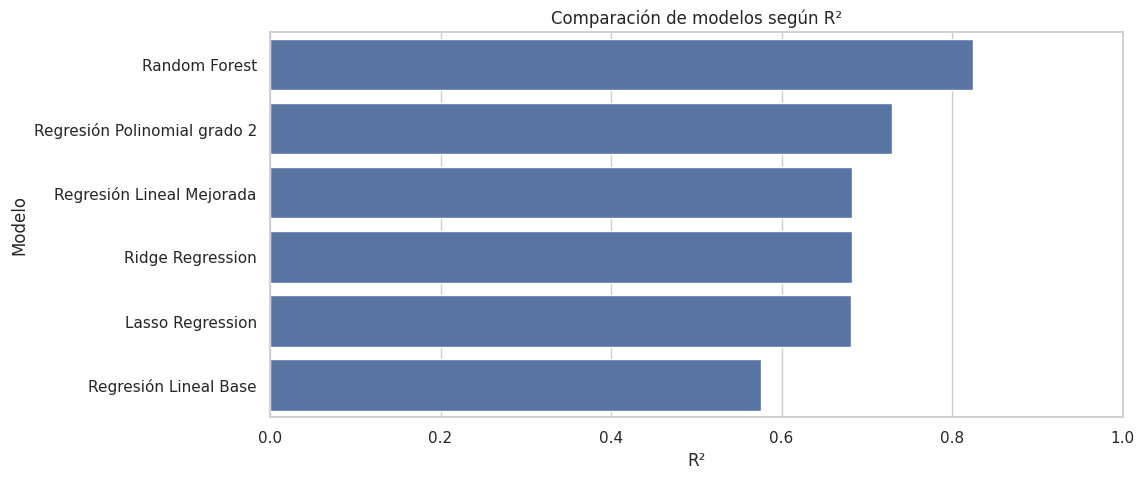

In [17]:
plt.figure(figsize=(11,5))
sns.barplot(data=comparacion, x="R2", y="Modelo")
plt.title("Comparación de modelos según R²")
plt.xlabel("R²")
plt.ylabel("Modelo")
plt.xlim(0, 1)
plt.show()

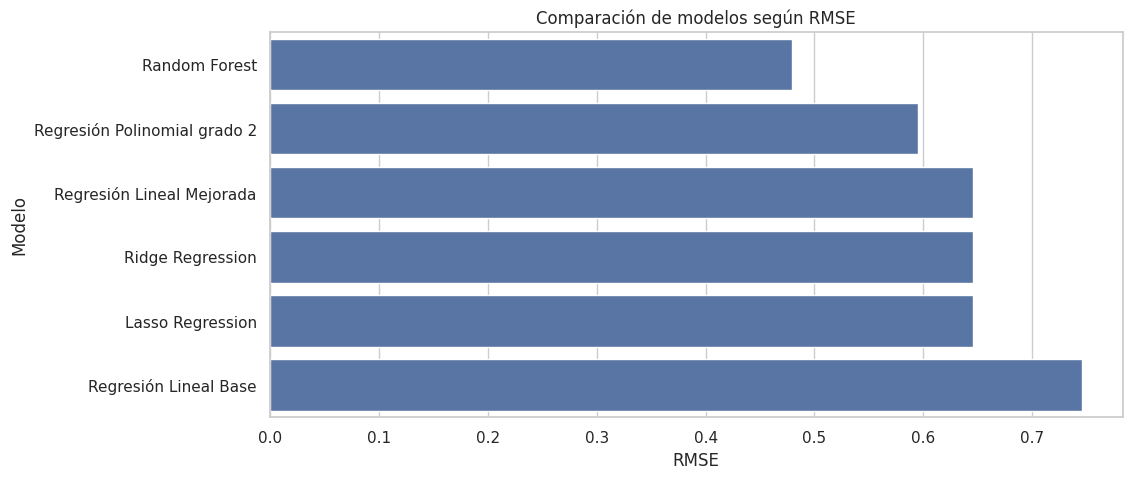

In [18]:
plt.figure(figsize=(11,5))
sns.barplot(data=comparacion.sort_values(by="RMSE"), x="RMSE", y="Modelo")
plt.title("Comparación de modelos según RMSE")
plt.xlabel("RMSE")
plt.ylabel("Modelo")
plt.show()

## 14. Gráfica del mejor modelo de regresión

En esta sección se grafica el mejor modelo de regresión obtenido, sin contar Random Forest.

Esto permite evaluar si realmente se logró mejorar la Regresión Lineal básica.


Mejor modelo de regresión: Regresión Polinomial grado 2


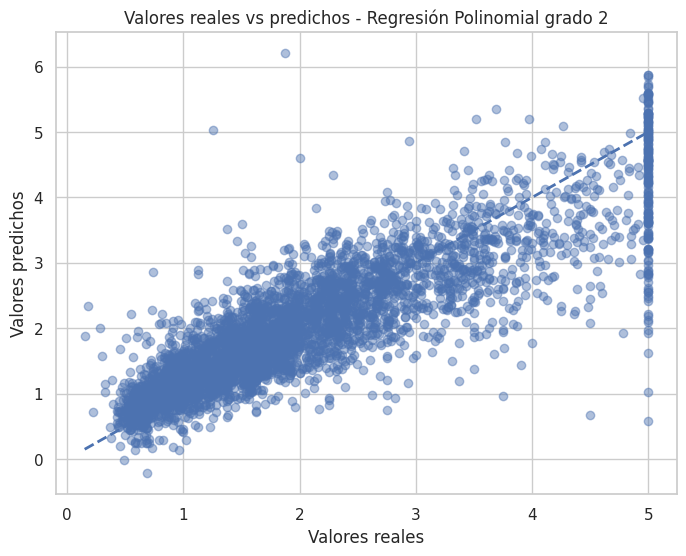

In [19]:
# Identificar el mejor modelo de regresión, excluyendo Random Forest
comparacion_regresiones = comparacion[comparacion["Modelo"] != "Random Forest"].copy()
mejor_regresion = comparacion_regresiones.iloc[0]["Modelo"]

print("Mejor modelo de regresión:", mejor_regresion)

# Seleccionar predicciones del mejor modelo
predicciones = {
    "Regresión Lineal Base": y_pred_lr,
    "Regresión Lineal Mejorada": y_pred_lr_mejorado,
    "Regresión Polinomial grado 2": y_pred_poly,
    "Ridge Regression": y_pred_ridge,
    "Lasso Regression": y_pred_lasso
}

y_pred_mejor = predicciones[mejor_regresion]

# Para el modelo base se usó y_test, para los demás y_test2
y_real = y_test if mejor_regresion == "Regresión Lineal Base" else y_test2

plt.figure(figsize=(8,6))
plt.scatter(y_real, y_pred_mejor, alpha=0.45)
plt.plot(
    [y_real.min(), y_real.max()],
    [y_real.min(), y_real.max()],
    linestyle="--",
    linewidth=2
)
plt.title(f"Valores reales vs predichos - {mejor_regresion}")
plt.xlabel("Valores reales")
plt.ylabel("Valores predichos")
plt.show()

## 15. Interpretación de resultados

En este apartado se interpreta el desempeño de los modelos.

La Regresión Lineal Base funciona como punto de partida.  
Después, al agregar ingeniería de características y modelos regularizados o polinomiales, se busca mejorar el R² y reducir los errores.

Si Random Forest obtiene el mejor desempeño, esto indica que el problema tiene relaciones no lineales importantes.


In [20]:
print("Resumen ordenado de mejor a peor modelo:")
display(comparacion)

print("\nMejor modelo general:")
display(comparacion.head(1))

print("\nMejor modelo de regresión, sin contar Random Forest:")
display(comparacion_regresiones.head(1))

Resumen ordenado de mejor a peor modelo:


,Modelo,MAE,MSE,RMSE,R2
5,Random Forest,0.306097,0.229987,0.479570,0.824492
2,Regresión Polinomial grado 2,0.418902,0.354599,0.595482,0.729398
1,Regresión Lineal Mejorada,0.462338,0.416438,0.645320,0.682207
3,Ridge Regression,0.462345,0.416444,0.645325,0.682203
4,Lasso Regression,0.462581,0.416785,0.645589,0.681943
0,Regresión Lineal Base,0.533200,0.555892,0.745581,0.575788



Mejor modelo general:


,Modelo,MAE,MSE,RMSE,R2
5,Random Forest,0.306097,0.229987,0.47957,0.824492



Mejor modelo de regresión, sin contar Random Forest:


,Modelo,MAE,MSE,RMSE,R2
2,Regresión Polinomial grado 2,0.418902,0.354599,0.595482,0.729398


# Conclusiones

En esta práctica se mejoró el análisis inicial de Regresión Lineal aplicado al dataset California Housing.

Primero se entrenó una Regresión Lineal básica para obtener una referencia del desempeño inicial. Posteriormente, se agregaron nuevas variables mediante ingeniería de características y se realizó un tratamiento básico de valores extremos.

También se evaluaron modelos como Regresión Polinomial, Ridge y Lasso, los cuales siguen perteneciendo al enfoque de regresión, pero permiten mejorar o estabilizar el comportamiento del modelo.

Finalmente, se compararon los resultados con Random Forest. Si este modelo obtiene el mejor resultado, se puede concluir que el problema presenta relaciones no lineales que una Regresión Lineal simple no logra capturar completamente.

En general, esta práctica demuestra que el desempeño de un modelo no depende únicamente del algoritmo, sino también del preprocesamiento, la creación de variables y la correcta evaluación mediante métricas como MAE, MSE, RMSE y R².
